In [13]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import random
from scipy.stats import kstest, wilcoxon, mannwhitneyu


In [3]:
def parse_file(lines_in):
    """
    Given a file of output from the R script panel_did2s.R, parse the output to determine the following quantities:

    * account ID
    * account status
    * number of control accounts studied
    * number of reposts studied
    * whether attention brokerage criteria C1-C4 were met
    * effect size for followers of the candidate account at t = 1
    * attention broker status (True/False)
    * number of failed attention brokerage criteria

    The relevant information will be returned in a dictionary. 
    Not all information may be present if output is truncated due to a lack of reposts or insufficient data for analysis.
    """
    acct_num = lines_in[1]

    if len(lines_in) < 3:
        return {
            'acct_num': acct_num,
            'status': 'no_json',
        }

    offset = 0
    if lines_in[4] == '"scaling controls down to 5000"':
        n_controls = 5000
        offset += 15

    else:
        n_controls = int(lines_in[3])

    if len(lines_in) < 7:
        return {
            'acct_num': acct_num,
            'status': 'no_analysis',
        }

    if lines_in[6 + offset] == '"testing if followers\' coeff at 0 significantly less than coeff at 1"':
        n_reposts = int(lines_in[5 + offset])
    elif lines_in[6 + offset] == '"scaling reposts down to 5000"':
        n_reposts = 5000
        offset += 15

    # C1 = whether followers' coeff at t=0 is significantly less than coeff at t=1
    sig_c1 = float(lines_in[8 + offset])

    # C2 = The effect size for attention broker followers at t=1 must be positive and statistically significant
    sig_c2 = float(lines_in[-1])
    effect_t1 = float(lines_in[-2])

    # C3 = effect at t=1 for followers must be significantly larger than effect at t=1 for non-followers.
    sig_c3 = float(lines_in[11 + offset])

    # C4 = For attention broker followers, the effect size at t=0 must be significantly larger than at t=-1
    sig_c4 = float(lines_in[14 + offset])

    ab = (sig_c1 < 0.05) & (sig_c2 < 0.05) & (sig_c3 < 0.05) & (sig_c4 < 0.05) & ((effect_t1 > 0) & (n_reposts + n_controls > 100))
    return {
        'status': 'success',
        'acct_num': acct_num,
        'n_controls': n_controls,
        'n_reposts': n_reposts,
        'C1': sig_c1,
        'C2': sig_c2,
        'C3': sig_c3,
        'C4': sig_c4,
        'tot_failed': (sig_c1 >= 0.05) + (sig_c3 >= 0.05) + (sig_c4 >= 0.05) + ((sig_c2 >= 0.05) | (effect_t1 <= 0) | (n_reposts + n_controls < 100)),
        'effect_size_t1': effect_t1,
        'ab': ab
    }

ix_res = []
for ix in range(100):
    with open(f"/home/nte5cp/attention-brokers-bsky/did2s_out/outf_{ix}.txt", "r") as f:
        lines = [l[4:].strip() for l in f.readlines()]
        ix_res.append(parse_file(lines))

        

## Collating & Summarizing Result Information

In [4]:
n_no_json = sum([i['status'] == 'no_json' for i in ix_res])
n_no_collation = sum([i['status'] == 'no_analysis' for i in ix_res])
print(f"{n_no_json} no repost file; {n_no_collation} no analysis")

ab_count = sum([i.get('ab', False) for i in ix_res])
print(f"{ab_count} attention brokers")

print("AB ranks:")
print([ix for ix, i in enumerate(ix_res) if i.get('ab', False)])

failed_c1 = sum([('C1' in i) & (i.get('C1', 0) >= 0.05) for i in ix_res])
print(f"{failed_c1} accounts failed C1")

failed_c2 = sum([('C2' in i) & (i.get('C2', 0) >= 0.05) for i in ix_res])
print(f"{failed_c2} accounts failed C2")

failed_c3 = sum([('C3' in i) & (i.get('C3', 0) >= 0.05) for i in ix_res])
print(f"{failed_c3} accounts failed C3")

failed_c4 = sum([('C4' in i) & (i.get('C4', 0) >= 0.05) & (i.get('effect_t1', -1) < 0)  for i in ix_res])
print(f"{failed_c4} accounts failed C4")

failed_1 = sum([i.get('tot_failed', 5) == 1 for i in ix_res])
failed_2 = sum([i.get('tot_failed', 5) == 2 for i in ix_res])
failed_3 = sum([i.get('tot_failed', 5) == 3 for i in ix_res])
failed_4 = sum([i.get('tot_failed', 5) == 4 for i in ix_res])

11 no repost file; 24 no analysis
10 attention brokers
AB ranks:
[1, 6, 7, 9, 10, 14, 51, 69, 73, 80]
51 accounts failed C1
1 accounts failed C2
49 accounts failed C3
14 accounts failed C4


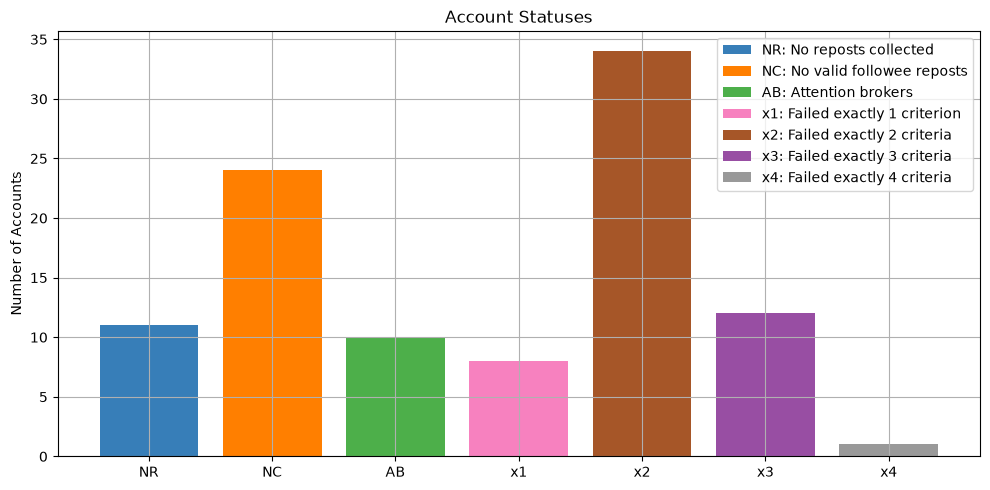

In [6]:
# Counting Accounts by Status
plt.rcParams['figure.figsize'] = (10, 5)
counts = [n_no_json, n_no_collation, ab_count, failed_1, failed_2, failed_3, failed_4]
labels = [
    'NR: No reposts collected',
    'NC: No valid followee reposts',
    'AB: Attention brokers',
    r"x1: Failed exactly 1 criterion",
    r"x2: Failed exactly 2 criteria",
    r"x3: Failed exactly 3 criteria",
    r"x4: Failed exactly 4 criteria",
]
plt.title("Account Statuses")
# sourced from https://gist.github.com/thriveth/8560036; color-blind friendly
colors = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.bar([i for i in range(7)], counts, color=colors, label=labels)
plt.grid()
plt.ylabel("Number of Accounts")
plt.xticks([i for i in range(7)], ['NR', 'NC', 'AB', 'x1', 'x2', 'x3', 'x4'])
plt.legend()
plt.tight_layout()
plt.savefig('./new_figs/account_statuses.pdf')

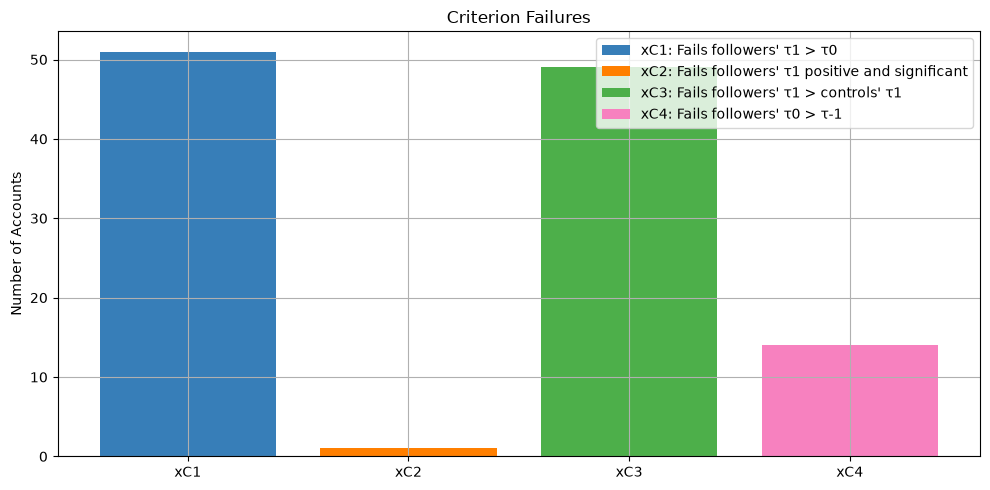

In [7]:
# Of the accounts with valid analyses that failed attention brokerage criteria, how many failed {1, 2, 3, 4} criteria?
plt.rcParams['figure.figsize'] = (10, 5)
counts = [failed_c1, failed_c2, failed_c3, failed_c4]
labels = [
    r"xC1: Fails followers' τ1 > τ0",
    r"xC2: Fails followers' τ1 positive and significant",
    r"xC3: Fails followers' τ1 > controls' τ1",
    r"xC4: Fails followers' τ0 > τ-1",
]
xticks = ['xC1', 'xC2', 'xC3', 'xC4']

plt.title("Criterion Failures")
colors = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
plt.bar([i for i in range(4)], counts, color=colors, label=labels)
plt.grid()
plt.ylabel("Number of Accounts")
plt.xticks([i for i in range(4)], xticks)
plt.legend()
plt.tight_layout()
plt.savefig('./new_figs/criterion_failures.pdf')

## Compare Effect Sizes between Attention Brokers and Non-Attention Brokers

In [10]:
def effect_size_to_percent_change(effect):
    # Use the coefficients from regressing on the log-scaled follower accumulation counts to obtain percent change in follower accumulation.
    return 100 * (np.exp(effect) - 1)
    
effect_sizes_abs = [effect_size_to_percent_change(i['effect_size_t1']) for i in ix_res if i.get('ab', False)]
effect_sizes_non = [effect_size_to_percent_change(i['effect_size_t1']) for i in ix_res if i.get('ab', -1) == False]

print(mannwhitneyu(effect_sizes_abs, y=effect_sizes_non, method='exact', alternative='greater'))

MannwhitneyuResult(statistic=np.float64(447.0), pvalue=np.float64(0.0005693364108386844))


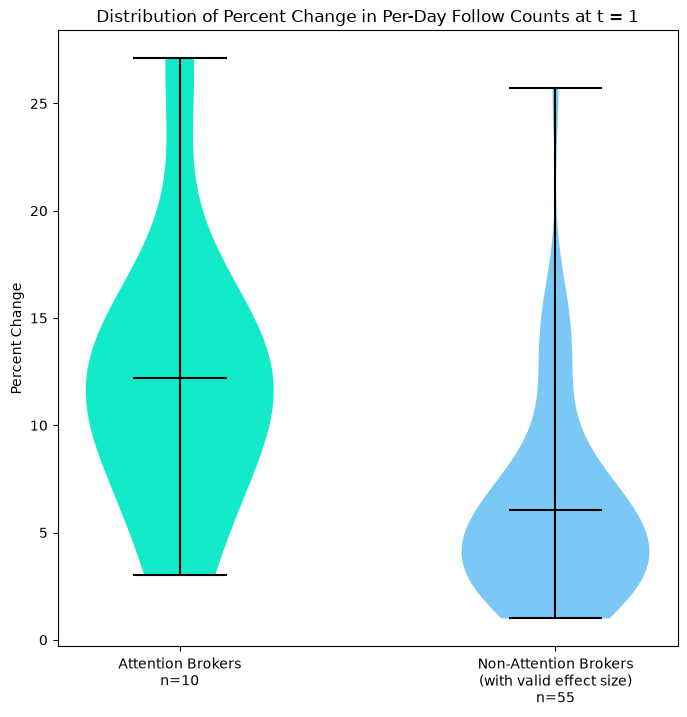

In [12]:
plt.rcParams['figure.figsize'] = (8, 8)

plt.violinplot(
    [effect_sizes_abs, effect_sizes_non], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Distribution of Percent Change in Per-Day Follow Counts at t = 1")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(effect_sizes_abs)}', f'Non-Attention Brokers\n(with valid effect size)\nn={len(effect_sizes_non)}'])
plt.ylabel("Percent Change")
plt.savefig('./pct_change_per_day_follow_accts_tau_1.pdf')